# Grid Matching & Preliminary Grid Feasibility – Version 1

## Objective
Enrich the mobility-driven candidate charging points with a first grid-feasibility layer by matching each candidate to the nearest distributor substation.

This layer evaluates whether the candidate locations identified from interurban coverage gaps appear more or less feasible from the grid side. It is **not yet the final siting or optimization solution**, but the infrastructure-feasibility step that informs it.

## Data sources
- Candidate charging points:  
  `candidate_points_v1.gpkg`
- Distributor capacity files:  
  `2026_04_01_R1299_demanda.csv`  
  `2026_04_01_R1005_generacion.csv`  
  `2026_04_01_R1-001_Demanda.csv`

## Variables inspected
- Candidate layer:  
  `geometry`, `candidate_id_n4`, `carretera`, `provincia`
- Distributor files:  
  substation name, municipality, province, coordinate fields, available capacity, occupied capacity, voltage level, comments

## Analytical logic adopted (v1)
The grid-feasibility layer is built in three steps:

1. **Standardise distributor tables**  
   Endesa, Viesgo, and i-DE files are converted into a common schema so that substations can be compared consistently

2. **Build a unified grid-node layer**  
   The three distributor datasets are merged and collapsed to unique substation nodes, preserving the main capacity and voltage information

3. **Match candidates to the nearest grid node**  
   Each candidate charging point is linked to its nearest substation using spatial nearest-neighbour matching in projected coordinates

## Preliminary thresholds adopted
A first-pass grid-status label is assigned using the published available-capacity field:

- `Sufficient` → available capacity ≥ 20 MW
- `Moderate` → 5 MW ≤ available capacity < 20 MW
- `Congested` → available capacity < 5 MW

## Justification
The project cannot stop at identifying mobility gaps alone.

A location may be strategically relevant for interurban EV travel, but still be difficult to develop if nearby grid capacity is weak. Matching candidate points to the nearest published grid node allows the analysis to move from a purely spatial mobility perspective to an initial infrastructure-planning perspective.

## Important caveat
This version uses **nearest-node Euclidean matching**, not full electrical-network modelling.

This means:
- the nearest substation is treated as the best available grid proxy  
- the classification relies on published distributor capacity fields only  
- some candidate points may match to multiple tied records where substations share the same location or distance

These limitations are acceptable for a first feasibility pass, but may be refined later if stricter reduction logic is required.

## Interpretation
This layer represents a **preliminary grid-feasibility diagnostic**, not the final charging proposal.

It defines:
- which grid node is closest to each candidate point  
- how far that candidate is from the matched node  
- what first-pass grid-status category the candidate receives  

It does **not yet** determine the final number of chargers or the final prioritised deployment plan.

## Outputs created
- Consolidated grid-node layer  
- Candidate-to-grid nearest-match layer  
- Preliminary `grid_status` classification for candidate points  

## Pending next step
Combine this grid-feasibility layer with the mandatory 2027 EV-demand projection so that the final proposal can balance mobility need, grid plausibility, and future charging demand.

In [1]:
import os
import re
import glob
import warnings
import unicodedata

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)

In [ ]:
print("Files currently available in /content:")
for f in sorted(os.listdir("/content")):
    print("-", f)

Files currently available in /content:
- .config
- 2026_04_01_R1-001_Demanda.csv
- 2026_04_01_R1005_generacion.csv
- 2026_04_01_R1299_demanda.csv
- candidate_points_v1.csv
- candidate_points_v1.gpkg
- mobility_backbone.gpkg
- sample_data


In [ ]:
CANDIDATES_FILE = "/content/candidate_points_v1.gpkg"
MOBILITY_FILE   = "/content/mobility_backbone.gpkg"

ENDESA_FILE = "/content/2026_04_01_R1299_demanda.csv"
VIESGO_FILE = "/content/2026_04_01_R1005_generacion.csv"
IDE_FILE    = "/content/2026_04_01_R1-001_Demanda.csv"

# CRS assumptions
ENDESA_UTM_EPSG = 25830
VIESGO_UTM_EPSG = 25830
IDE_UTM_EPSG    = 25830

# Thresholds for preliminary grid status
SUFFICIENT_THRESHOLD_MW = 20.0
MODERATE_THRESHOLD_MW   = 5.0

# Notebook 4 outputs saved directly to /content
OUT_GRID_GPKG  = "/content/grid_nodes_v1.gpkg"
OUT_GRID_CSV   = "/content/grid_nodes_v1.csv"
OUT_MATCH_GPKG = "/content/candidate_points_grid_matched_v1.gpkg"
OUT_MATCH_CSV  = "/content/candidate_points_grid_matched_v1.csv"

# Validate required inputs
required_inputs = [CANDIDATES_FILE, ENDESA_FILE, VIESGO_FILE, IDE_FILE]
missing_inputs = [p for p in required_inputs if not os.path.exists(p)]

if missing_inputs:
    raise FileNotFoundError(
        "Upload these files into the Colab sidebar first:\n- " + "\n- ".join(missing_inputs)
    )

print("All required inputs are available.")

All required inputs are available.


In [ ]:
def read_table(path):
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    encodings = ["utf-8", "latin1", "cp1252"]
    separators = [";", ",", "\t", "|"]

    last_error = None

    for enc in encodings:
        for sep in separators:
            try:
                df = pd.read_csv(
                    path,
                    sep=sep,
                    encoding=enc,
                    engine="python"
                )
                if df.shape[1] >= 5:
                    return df
            except Exception as e:
                last_error = e
                continue

    raise last_error

## Load the candidate layer from Notebook 3

The input to this notebook is the set of candidate charging points generated from uncovered interurban corridors in Notebook 3.

At this stage, the candidate set is still mobility-driven only.  
The goal here is to test whether those locations appear plausible from the grid side.

In [ ]:
candidate_gdf = gpd.read_file(CANDIDATES_FILE)
candidate_gdf = candidate_gdf.reset_index(drop=True)

if "candidate_id_n4" not in candidate_gdf.columns:
    candidate_gdf["candidate_id_n4"] = np.arange(1, len(candidate_gdf) + 1)

print("Candidate points:", len(candidate_gdf))
print("Candidate CRS:", candidate_gdf.crs)
display(candidate_gdf.head())

mobility_gdf = None
if os.path.exists(MOBILITY_FILE):
    mobility_gdf = gpd.read_file(MOBILITY_FILE)
    print("Mobility backbone loaded:", len(mobility_gdf))

Candidate points: 57
Candidate CRS: EPSG:25830


,index_right,id_catalog,carretera,clase,provincia,dist_to_backbone_m,geometry,candidate_id_n4
0,3001,5545404112D766B32749F9697505489A,A-66,Autovía,Cáceres,5.990023e-11,POINT Z (227810.363 4427221.642 0),1
1,3542,5545404118556C932749F96974051277,A-66,Autovía,León,7.478352e-12,POINT Z (286324.03 4695860.79 0),2
2,3838,554540411875EEB92749F96975054D28,A-66,Autovía,Cáceres,5.327118e-11,POINT Z (208741.572 4406122.534 0),3
3,4188,5545404118DF66332749F96975055401,A-66,Autovía,Cáceres,1.524195e-10,POINT Z (212095.793 4359948.648 0),4
4,5529,5545404138D7CE192749F9697405168F,A-66,Autovía,Zamora,2.912580e-10,POINT Z (281600.924 4646953.79 0),5


Mobility backbone loaded: 6896


In [ ]:
candidate_gdf = candidate_gdf.drop(columns=["index_right"], errors="ignore")
candidate_gdf.head()

,id_catalog,carretera,clase,provincia,dist_to_backbone_m,geometry,candidate_id_n4
0,5545404112D766B32749F9697505489A,A-66,Autovía,Cáceres,5.990023e-11,POINT Z (227810.363 4427221.642 0),1
1,5545404118556C932749F96974051277,A-66,Autovía,León,7.478352e-12,POINT Z (286324.03 4695860.79 0),2
2,554540411875EEB92749F96975054D28,A-66,Autovía,Cáceres,5.327118e-11,POINT Z (208741.572 4406122.534 0),3
3,5545404118DF66332749F96975055401,A-66,Autovía,Cáceres,1.524195e-10,POINT Z (212095.793 4359948.648 0),4
4,5545404138D7CE192749F9697405168F,A-66,Autovía,Zamora,2.912580e-10,POINT Z (281600.924 4646953.79 0),5


In [ ]:
endesa_raw = read_table(ENDESA_FILE)
viesgo_raw = read_table(VIESGO_FILE)
ide_raw    = read_table(IDE_FILE)

print("Endesa raw shape:", endesa_raw.shape)
print("Viesgo raw shape:", viesgo_raw.shape)
print("i-DE raw shape:", ide_raw.shape)

display(endesa_raw.head(3))
display(viesgo_raw.head(3))
display(ide_raw.head(3))

Endesa raw shape: (1839, 19)
Viesgo raw shape: (178, 22)
i-DE raw shape: (3019, 17)


,Gestor de red,Provincia,Municipio,Coordenada UTM X,Coordenada UTM Y,Subestación,Nivel de Tensión (kV),Capacidad firme disponible (MW),Capacidad comprometida por cuestiones regulatorias,Capacidad de acceso firme de demanda ocupada (MW),Capacidad de acceso firme admitida y no evaluada (MW),Posiciones ocupadas,Posiciones libres,Nudo 0*,Comentarios,Comunidad Autónoma,Nombre Subestación,Provincia.1,Municipio.1
0,R1-299,4,4079,"535771,67","4074262,07",58038225,66,"0,00",0,"0,00","0,00",NaN,NaN,0,,01 - Andalucía,AGUADULC,Almería,Roquetas de Mar
1,R1-299,4,4079,"535771,67","4074262,07",58038225,20,"0,00",0,"59,66","0,00",NaN,NaN,0,,01 - Andalucía,AGUADULC,Almería,Roquetas de Mar
2,R1-299,4,4006,"575906,01","4135997,40",510032846,66,"0,00",0,"0,76","0,00",NaN,NaN,0,,01 - Andalucía,ALBOX,Almería,Albox


,Gestor de red,Provincia,Municipio,Coordenada UTM X,Coordenada UTM Y,Subestación,Nivel de Tensión (kV),Capacidad disponible (MW),Capacidad comprometida por cuestiones regulatorias,Capacidad ocupada (MW),Capacidad admitida y no resuelta (MW),Posiciones ocupadas,Posiciones libres,Nudo Afección RdT,Nudo limitado por Scc,Nudo 0*,Comentarios,Nombre Subestación,Capacidad admitida y no resuelta (MW) \nEólica,Capacidad admitida y no resuelta (MW)\n Solar,Capacidad admitida y no resuelta (MW) \nAlmacenamiento,Capacidad admitida y no resuelta (MW) \nOtras
0,R1-005,Asturias,Valdés,"215.356,7","4.825.840,4",101.0,20.0,0,1.0,0,0,NaN,NaN,Salas 400 kV,0.0,0.0,Afección a nudo concurso capacidad,ALMUÑA,0,0,0,0.0
1,R1-005,Asturias,Valdés,"215.356,7","4.825.840,4",101.0,132.0,0,1.0,0,0,NaN,NaN,Salas 400 kV,0.0,1.0,Afección a nudo concurso capacidad,ALMUÑA,0,0,0,0.0
2,R1-005,Asturias,Coaña,"198.270,1","4.820.751,9",158.0,30.0,0,1.0,24,0,NaN,NaN,Salas 400 kV,0.0,0.0,Afección a nudo concurso capacidad,ARBON,0,0,0,0.0


,Gestor de red,Provincia,Municipio,Coordenada UTM X,Coordenada UTM Y,Subestación,Nivel de Tensión (kV),Capacidad firme disponible (MW),Capacidad comprometida por cuestiones regulatorias,Capacidad de acceso firme de demanda ocupada (MW),Capacidad de acceso firme admitida y no evaluada (MW),Posiciones ocupadas,Posiciones libres,Nudo 0*,Comentarios,Denominación del Punto de Conexión,Identificador del Punto de Conexión
0,R1-001,Araba/Álava,Ayala/Aiara,"499100,028809514","4770106,21764367",3102,30,0,0,"60,19",0,NaN,NaN,0,NaN,ST AIALA 30.000,25740000
1,R1-001,Araba/Álava,Vitoria-Gasteiz,"523922,106338171","4744874,00934341",3017,"13,2",0,0,15,0,NaN,NaN,0,NaN,ALI T3,101065005
2,R1-001,Araba/Álava,Vitoria-Gasteiz,"523922,106338171","4744874,00934341",3017,30,0,0,"72,62",0,NaN,NaN,1,NaN,ALI T3 30.000,25230001


## Standardize the distributor tables

Endesa, Viesgo, and i-DE publish capacity data with different column names and structures.

This block converts all three sources into the same schema:
- distributor name
- province and municipality
- substation name
- available capacity
- occupied capacity
- voltage level
- coordinates

This makes the three networks comparable in one unified layer.

In [ ]:
def clean_colname(c):
    c = str(c).replace("\n", " ").replace("\xa0", " ").strip()
    c = re.sub(r"\s+", " ", c)
    return c


def parse_spanish_number(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip().replace("\xa0", "").replace(" ", "")
    if s in {"", "-", "nan", "NaN", "None"}:
        return np.nan

    # Spanish-style numbers:
    # 215.356,7 -> 215356.7
    # 499100,028 -> 499100.028
    if "," in s and "." in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        s = s.replace(",", "")

    return pd.to_numeric(s, errors="coerce")


def to_wgs84_from_utm(df, x_col, y_col, utm_epsg):
    tmp = df.copy()
    tmp["x_num"] = tmp[x_col].apply(parse_spanish_number)
    tmp["y_num"] = tmp[y_col].apply(parse_spanish_number)

    valid = tmp["x_num"].notna() & tmp["y_num"].notna()

    gdf = gpd.GeoDataFrame(
        tmp.loc[valid].copy(),
        geometry=gpd.points_from_xy(tmp.loc[valid, "x_num"], tmp.loc[valid, "y_num"]),
        crs=utm_epsg
    ).to_crs(4326)

    tmp["lon"] = np.nan
    tmp["lat"] = np.nan
    tmp.loc[valid, "lon"] = gdf.geometry.x.values
    tmp.loc[valid, "lat"] = gdf.geometry.y.values
    tmp["coord_valid"] = valid

    return tmp


def standardize_grid_table(df, distributor_name, utm_epsg):
    df = df.copy()
    df.columns = [clean_colname(c) for c in df.columns]

    # common coordinate conversion
    df = to_wgs84_from_utm(df, "Coordenada UTM X", "Coordenada UTM Y", utm_epsg)

    # provider-specific schema mapping
    if distributor_name == "Endesa":
        substation_name_col = "Nombre Subestación"
        available_col = "Capacidad firme disponible (MW)"
        occupied_col = "Capacidad de acceso firme de demanda ocupada (MW)"
        voltage_col = "Nivel de Tensión (kV)"
        province_col = "Provincia.1" if "Provincia.1" in df.columns else "Provincia"
        municipality_col = "Municipio.1" if "Municipio.1" in df.columns else "Municipio"
        comments_col = "Comentarios" if "Comentarios" in df.columns else None

    elif distributor_name == "Viesgo":
        substation_name_col = "Nombre Subestación"
        available_col = "Capacidad disponible (MW)"
        occupied_col = "Capacidad ocupada (MW)"
        voltage_col = "Nivel de Tensión (kV)"
        province_col = "Provincia"
        municipality_col = "Municipio"
        comments_col = "Comentarios" if "Comentarios" in df.columns else None

    elif distributor_name == "i-DE":
        substation_name_col = "Denominación del Punto de Conexión"
        available_col = "Capacidad firme disponible (MW)"
        occupied_col = "Capacidad de acceso firme de demanda ocupada (MW)"
        voltage_col = "Nivel de Tensión (kV)"
        province_col = "Provincia"
        municipality_col = "Municipio"
        comments_col = "Comentarios" if "Comentarios" in df.columns else None

    else:
        raise ValueError(f"Unknown distributor_name: {distributor_name}")

    out = pd.DataFrame({
        "distributor_network": distributor_name,
        "province": df[province_col] if province_col in df.columns else np.nan,
        "municipality": df[municipality_col] if municipality_col in df.columns else np.nan,
        "substation_name": df[substation_name_col] if substation_name_col in df.columns else np.nan,
        "available_capacity_mw": df[available_col].apply(parse_spanish_number) if available_col in df.columns else np.nan,
        "occupied_capacity_mw": df[occupied_col].apply(parse_spanish_number) if occupied_col in df.columns else np.nan,
        "voltage_kv": df[voltage_col].apply(parse_spanish_number) if voltage_col in df.columns else np.nan,
        "comments": df[comments_col] if comments_col else np.nan,
        "lat": df["lat"],
        "lon": df["lon"],
        "coord_valid": df["coord_valid"]
    })

    return out

In [ ]:
endesa_std = standardize_grid_table(endesa_raw, "Endesa", utm_epsg=ENDESA_UTM_EPSG)
viesgo_std = standardize_grid_table(viesgo_raw, "Viesgo", utm_epsg=VIESGO_UTM_EPSG)
ide_std    = standardize_grid_table(ide_raw, "i-DE",   utm_epsg=IDE_UTM_EPSG)

print("Endesa standardized:", endesa_std.shape)
print("Viesgo standardized:", viesgo_std.shape)
print("i-DE standardized:", ide_std.shape)

display(endesa_std.head(3))
display(viesgo_std.head(3))
display(ide_std.head(3))

Endesa standardized: (1839, 11)
Viesgo standardized: (178, 11)
i-DE standardized: (3019, 11)


,distributor_network,province,municipality,substation_name,available_capacity_mw,occupied_capacity_mw,voltage_kv,comments,lat,lon,coord_valid
0,Endesa,Almería,Roquetas de Mar,AGUADULC,0.0,0.00,66.0,,36.813531,-2.598941,True
1,Endesa,Almería,Roquetas de Mar,AGUADULC,0.0,59.66,20.0,,36.813531,-2.598941,True
2,Endesa,Almería,Albox,ALBOX,0.0,0.76,66.0,,37.367600,-2.142758,True


,distributor_network,province,municipality,substation_name,available_capacity_mw,occupied_capacity_mw,voltage_kv,comments,lat,lon,coord_valid
0,Viesgo,Asturias,Valdés,ALMUÑA,0.0,0.0,20.0,Afección a nudo concurso capacidad,43.531231,-6.522581,True
1,Viesgo,Asturias,Valdés,ALMUÑA,0.0,0.0,132.0,Afección a nudo concurso capacidad,43.531231,-6.522581,True
2,Viesgo,Asturias,Coaña,ARBON,0.0,24.0,30.0,Afección a nudo concurso capacidad,43.478805,-6.730785,True


,distributor_network,province,municipality,substation_name,available_capacity_mw,occupied_capacity_mw,voltage_kv,comments,lat,lon,coord_valid
0,i-DE,Araba/Álava,Ayala/Aiara,ST AIALA 30.000,0.0,60.19,30.0,NaN,43.083669,-3.011056,True
1,i-DE,Araba/Álava,Vitoria-Gasteiz,ALI T3,0.0,15.00,13.2,NaN,42.856076,-2.707190,True
2,i-DE,Araba/Álava,Vitoria-Gasteiz,ALI T3 30.000,0.0,72.62,30.0,NaN,42.856076,-2.707190,True


In [ ]:
required_cols = [
    "province", "municipality", "substation_name",
    "available_capacity_mw", "occupied_capacity_mw",
    "lat", "lon", "coord_valid"
]

for name, df in [("Endesa", endesa_std), ("Viesgo", viesgo_std), ("i-DE", ide_std)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name}: missing required columns -> {missing}")

    if df["substation_name"].isna().all():
        raise ValueError(f"{name}: all substation_name values are NaN")

    if df["lat"].isna().all() or df["lon"].isna().all():
        raise ValueError(f"{name}: all coordinates are NaN")

    print(f"{name} passed schema checks.")

Endesa passed schema checks.
Viesgo passed schema checks.
i-DE passed schema checks.


### Interpretation — standardization worked

At this stage, the three distributor files have been converted into one common structure. This matters because the raw files do not use the same schema, and without standardization they cannot be combined into a single comparable grid-node layer.

The most important validation point here is not the row count itself, but whether the standardized tables now contain meaningful substation names, usable capacity fields, and valid coordinates. In particular, fixing the Endesa schema was essential, because earlier versions produced missing capacities and unrealistic nearest-node matches.

In [ ]:
grid_all = pd.concat([endesa_std, viesgo_std, ide_std], ignore_index=True)

# keep only rows that have the essentials
grid_all = grid_all.dropna(subset=["substation_name", "available_capacity_mw", "lat", "lon"])
grid_all = grid_all[grid_all["coord_valid"]].copy()

print("Combined grid rows (before substation collapse):", len(grid_all))
display(grid_all.head())

Combined grid rows (before substation collapse): 5035


,distributor_network,province,municipality,substation_name,available_capacity_mw,occupied_capacity_mw,voltage_kv,comments,lat,lon,coord_valid
0,Endesa,Almería,Roquetas de Mar,AGUADULC,0.0,0.00,66.0,,36.813531,-2.598941,True
1,Endesa,Almería,Roquetas de Mar,AGUADULC,0.0,59.66,20.0,,36.813531,-2.598941,True
2,Endesa,Almería,Albox,ALBOX,0.0,0.76,66.0,,37.367600,-2.142758,True
3,Endesa,Almería,Albox,ALBOX,0.0,14.86,25.0,,37.367600,-2.142758,True
4,Endesa,Almería,Alcolea,ALCOLEA,0.0,0.00,66.0,,36.969459,-2.963403,True


In [ ]:
def voltage_string(s):
    vals = []
    for v in s.dropna():
        try:
            fv = float(v)
            vals.append(str(int(fv)) if fv.is_integer() else str(fv))
        except:
            vals.append(str(v))
    return ", ".join(sorted(set(vals), key=lambda x: (len(x), x)))


def first_nonempty(s):
    for x in s:
        if pd.notna(x) and str(x).strip() not in {"", "nan", "None"}:
            return str(x).strip()
    return ""


def join_unique_text(s):
    vals = []
    for x in s.dropna():
        x = str(x).strip()
        if x and x not in vals:
            vals.append(x)
    return " | ".join(vals)


def normalize_node_name(name):
    if pd.isna(name):
        return None

    s = str(name).upper().strip()
    s = re.sub(r"\s+", " ", s)

    # remove transformer labels like T1, T2, T3
    s = re.sub(r"\bT\d+\b", "", s)

    # remove trailing voltage-like token such as 13, 13.2, 20, 30.000, 45, 66, 132
    s = re.sub(r"\s+\d[\d\.,]*$", "", s)

    s = re.sub(r"\s+", " ", s).strip(" -_/")
    return s


grid_all["physical_node_name"] = grid_all["substation_name"].apply(normalize_node_name)
grid_all["physical_node_name"] = grid_all["physical_node_name"].fillna(grid_all["substation_name"])

grid_nodes = (
    grid_all
    .sort_values(
        ["distributor_network", "physical_node_name", "available_capacity_mw"],
        ascending=[True, True, False]
    )
    .groupby(
        ["distributor_network", "province", "municipality", "physical_node_name", "lat", "lon"],
        as_index=False
    )
    .agg(
        available_capacity_mw=("available_capacity_mw", "max"),
        occupied_capacity_mw=("occupied_capacity_mw", "max"),
        voltage_levels=("voltage_kv", voltage_string),
        n_raw_rows=("substation_name", "size"),
        source_substation_names=("substation_name", join_unique_text),
        comments=("comments", first_nonempty)
    )
    .rename(columns={"physical_node_name": "substation_name"})
)

print("Unique physical grid nodes:", len(grid_nodes))
display(grid_nodes.head(10))

Unique physical grid nodes: 2503


,distributor_network,province,municipality,substation_name,lat,lon,available_capacity_mw,occupied_capacity_mw,voltage_levels,n_raw_rows,source_substation_names,comments
0,Endesa,A Coruña,"Pontes de García Rodríguez, As",TESOURO,43.452366,-7.892504,0.0,18.00,"20, 132",2,TESOURO,
1,Endesa,Almería,Albox,ALBOX,37.367600,-2.142758,0.0,14.86,"25, 66",2,ALBOX,
2,Endesa,Almería,Alcolea,ALCOLEA,36.969459,-2.963403,0.0,6.41,"20, 66",2,ALCOLEA,
3,Endesa,Almería,Almería,ANDARAX,36.839727,-2.431844,0.0,54.25,"20, 66, 132",3,ANDARAX,
4,Endesa,Almería,Almería,BELEN,36.850365,-2.474578,0.0,43.16,"20, 66",2,BELEN,
5,Endesa,Almería,Almería,DESALADO,36.816103,-2.424811,0.0,1.83,66,1,DESALADO,
6,Endesa,Almería,Almería,MOLINOS,36.862946,-2.437535,0.0,18.95,"20, 132",2,MOLINOS,
7,Endesa,Almería,Almería,S_TOMAS,36.823660,-2.443101,0.0,37.65,"20, 66",2,S_TOMAS,
8,Endesa,Almería,Almería,TORRECAR,36.867629,-2.448961,0.0,37.51,"20, 66",2,TORRECAR,
9,Endesa,Almería,Almería,TOYO,36.859749,-2.330552,0.0,53.10,"20, 132",2,TOYO,


### Interpretation — one physical node per substation

The raw distributor files often report the same physical substation in multiple rows because different voltage levels are listed separately. If we matched candidates directly to those raw rows, the nearest-node logic would become noisy and potentially misleading.

Collapsing the data to one row per physical grid node gives us a cleaner planning layer. This means the matching step that follows is no longer choosing between duplicated technical records, but between distinct physical substations.

In [ ]:
display(
    grid_nodes[
        ["distributor_network", "province", "municipality", "substation_name", "source_substation_names", "n_raw_rows"]
    ].head(15)
)

,distributor_network,province,municipality,substation_name,source_substation_names,n_raw_rows
0,Endesa,A Coruña,"Pontes de García Rodríguez, As",TESOURO,TESOURO,2
1,Endesa,Almería,Albox,ALBOX,ALBOX,2
2,Endesa,Almería,Alcolea,ALCOLEA,ALCOLEA,2
3,Endesa,Almería,Almería,ANDARAX,ANDARAX,3
4,Endesa,Almería,Almería,BELEN,BELEN,2
5,Endesa,Almería,Almería,DESALADO,DESALADO,1
6,Endesa,Almería,Almería,MOLINOS,MOLINOS,2
7,Endesa,Almería,Almería,S_TOMAS,S_TOMAS,2
8,Endesa,Almería,Almería,TORRECAR,TORRECAR,2
9,Endesa,Almería,Almería,TOYO,TOYO,2


In [ ]:
grid_nodes_gdf = gpd.GeoDataFrame(
    grid_nodes,
    geometry=gpd.points_from_xy(grid_nodes["lon"], grid_nodes["lat"]),
    crs=4326
)

grid_nodes_gdf.to_file(OUT_GRID_GPKG, driver="GPKG")
grid_nodes.drop(columns="geometry", errors="ignore").to_csv(OUT_GRID_CSV, index=False)

print("Saved:")
print("-", OUT_GRID_GPKG)
print("-", OUT_GRID_CSV)

Saved:
- /content/grid_nodes_v1.gpkg
- /content/grid_nodes_v1.csv


In [ ]:
grid_nodes_proj = grid_nodes_gdf.to_crs(candidate_gdf.crs)

candidate_base = candidate_gdf.drop(columns=["index_right"], errors="ignore").copy()
grid_nodes_proj = grid_nodes_proj.drop(columns=["index_right"], errors="ignore").copy()

matched_raw = gpd.sjoin_nearest(
    candidate_base,
    grid_nodes_proj[
        [
            "distributor_network",
            "province",
            "municipality",
            "substation_name",
            "available_capacity_mw",
            "occupied_capacity_mw",
            "voltage_levels",
            "n_raw_rows",
            "source_substation_names",
            "comments",
            "geometry"
        ]
    ],
    how="left",
    distance_col="dist_to_grid_m"
)

matched_raw = matched_raw.drop(columns=["index_right"], errors="ignore")
matched_raw["dist_to_grid_km"] = matched_raw["dist_to_grid_m"] / 1000.0

print("Rows returned by nearest join:", len(matched_raw))
print("Unique candidate ids:", matched_raw["candidate_id_n4"].nunique())

display(
    matched_raw[
        [
            "candidate_id_n4",
            "carretera",
            "substation_name",
            "available_capacity_mw",
            "dist_to_grid_km"
        ]
    ].head(10)
)

Rows returned by nearest join: 62
Unique candidate ids: 57


,candidate_id_n4,carretera,substation_name,available_capacity_mw,dist_to_grid_km
0,1,A-66,GALISTEO,0.0,8.148174
1,2,A-66,VILLAMAÑAN,0.0,7.636217
2,3,A-66,CASAR CACERES,0.0,22.649347
3,4,A-66,CACERES2,0.0,13.336674
4,5,A-66,VENTOSA,0.0,6.283722
5,6,A-66,CASTELLANOS,0.0,12.939568
6,7,A-66,CORRALES,0.0,3.087142
7,8,A-7,GUALCHOS,0.0,12.258611
8,9,A-7,CONJURO,0.0,3.206971
9,10,A-7,ALMUNECA,0.0,2.104539


In [ ]:
tie_counts = (
    matched_raw.groupby("candidate_id_n4")
    .size()
    .rename("n_equal_nearest_nodes")
    .reset_index()
)

matched_gdf = (
    matched_raw
    .sort_values(
        [
            "candidate_id_n4",
            "dist_to_grid_m",
            "available_capacity_mw",
            "occupied_capacity_mw",
            "substation_name"
        ],
        ascending=[True, True, False, True, True]
    )
    .drop_duplicates(subset=["candidate_id_n4"], keep="first")
    .merge(tie_counts, on="candidate_id_n4", how="left")
    .reset_index(drop=True)
)

matched_gdf["dist_to_grid_km"] = matched_gdf["dist_to_grid_m"] / 1000.0

print("Final matched rows:", len(matched_gdf))
print("Unique candidate ids:", matched_gdf["candidate_id_n4"].nunique())
print("Candidates with tied nearest nodes:", (matched_gdf["n_equal_nearest_nodes"] > 1).sum())

display(
    matched_gdf[
        [
            "candidate_id_n4",
            "carretera",
            "substation_name",
            "available_capacity_mw",
            "dist_to_grid_km",
            "n_equal_nearest_nodes"
        ]
    ].head(15)
)

Final matched rows: 57
Unique candidate ids: 57
Candidates with tied nearest nodes: 5


,candidate_id_n4,carretera,substation_name,available_capacity_mw,dist_to_grid_km,n_equal_nearest_nodes
0,1,A-66,GALISTEO,0.00,8.148174,1
1,2,A-66,VILLAMAÑAN,0.00,7.636217,1
2,3,A-66,CASAR CACERES,0.00,22.649347,1
3,4,A-66,CACERES2,0.00,13.336674,1
4,5,A-66,VENTOSA,0.00,6.283722,1
5,6,A-66,CASTELLANOS,0.00,12.939568,1
6,7,A-66,CORRALES,0.00,3.087142,1
7,8,A-7,GUALCHOS,0.00,12.258611,1
8,9,A-7,CONJURO,0.00,3.206971,1
9,10,A-7,ALMUNECA,0.00,2.104539,1


## Threshold rule used for `grid_status`

Following the datathon rules, `grid_status` is assigned from the available-capacity field of the nearest matched distributor node. In this notebook, the thresholds are defined as follows:

- **Sufficient**: available capacity >= 20 MW  
- **Moderate**: available capacity >= 5 MW and < 20 MW  
- **Congested**: available capacity < 5 MW  

These thresholds are used here as a first planning rule and will need to be justified explicitly in the final report. A value of `0.0 MW` does not mean the node is missing; it means the node exists but reports no spare available capacity for new connection in the field used for classification.

In [ ]:
def classify_grid_status(cap_mw):
    if pd.isna(cap_mw):
        return "Congested"
    elif cap_mw >= SUFFICIENT_THRESHOLD_MW:
        return "Sufficient"
    elif cap_mw >= MODERATE_THRESHOLD_MW:
        return "Moderate"
    else:
        return "Congested"


matched_gdf["grid_status"] = matched_gdf["available_capacity_mw"].apply(classify_grid_status)

matched_gdf["grid_match_flag"] = np.select(
    [
        matched_gdf["dist_to_grid_km"].isna(),
        matched_gdf["dist_to_grid_km"] > 15,
        matched_gdf["dist_to_grid_km"] > 5
    ],
    [
        "No matched node",
        "Far from nearest node",
        "Medium distance to node"
    ],
    default="Near node"
)

# Candidate coordinates in WGS84 for later output files
matched_wgs84 = matched_gdf.to_crs(4326)
matched_gdf["latitude"] = matched_wgs84.geometry.y
matched_gdf["longitude"] = matched_wgs84.geometry.x

summary = (
    matched_gdf["grid_status"]
    .value_counts(dropna=False)
    .rename_axis("grid_status")
    .reset_index(name="n_candidates")
)

print("Grid-status summary")
display(summary)

print("\nDistance summary (km)")
display(matched_gdf["dist_to_grid_km"].describe())

print("\nGrid-match diagnostic summary")
display(
    matched_gdf["grid_match_flag"]
    .value_counts(dropna=False)
    .rename_axis("grid_match_flag")
    .reset_index(name="n_candidates")
)

Grid-status summary


,grid_status,n_candidates
0,Congested,53
1,Sufficient,4



Distance summary (km)


,dist_to_grid_km
count,57.000000
mean,12.302253
std,7.516140
min,2.104539
25%,6.661544
50%,10.336364
75%,15.790794
max,38.313418



Grid-match diagnostic summary


,grid_match_flag,n_candidates
0,Medium distance to node,33
1,Far from nearest node,16
2,Near node,8


### Interpretation — what the matching result tells us

This notebook shows that many of the mobility-driven candidate points remain weak from the grid perspective. In the current run, most candidates are matched to nearby substations reporting `0.0 MW` available capacity, which under our threshold rule places them in the `Congested` category rather than `Sufficient`.

This is an important analytical result, not a failure of the notebook. It means that mobility need and grid feasibility do not align automatically. In other words, several corridors where new chargers appear desirable from a coverage perspective also look constrained from the infrastructure side.

A second important result is that the corrected Endesa matching substantially improved the geography of the solution. The mean nearest-grid distance became much more realistic, which makes the current feasibility labels more trustworthy than the earlier run.

In [ ]:
print("\nMatched available-capacity distribution")
display(
    matched_gdf["available_capacity_mw"]
    .value_counts(dropna=False)
    .rename_axis("available_capacity_mw")
    .reset_index(name="n_candidates")
    .sort_values("available_capacity_mw", na_position="last")
)


Matched available-capacity distribution


,available_capacity_mw,n_candidates
0,0.00,53
1,20.30,2
2,21.27,1
3,35.00,1


In [ ]:
cols_to_show = [
    "candidate_id_n4",
    "carretera",
    "provincia",
    "distributor_network",
    "substation_name",
    "available_capacity_mw",
    "dist_to_grid_km",
    "grid_status",
    "latitude",
    "longitude"
]

display(matched_gdf[cols_to_show].head(15))

,candidate_id_n4,carretera,provincia,distributor_network,substation_name,available_capacity_mw,dist_to_grid_km,grid_status,latitude,longitude
0,1,A-66,Cáceres,i-DE,GALISTEO,0.00,8.148174,Congested,39.951364,-6.186186
1,2,A-66,León,i-DE,VILLAMAÑAN,0.00,7.636217,Congested,42.385657,-5.595729
2,3,A-66,Cáceres,i-DE,CASAR CACERES,0.00,22.649347,Congested,39.755251,-6.399656
3,4,A-66,Cáceres,i-DE,CACERES2,0.00,13.336674,Congested,39.341053,-6.340569
4,5,A-66,Zamora,i-DE,VENTOSA,0.00,6.283722,Congested,41.944338,-5.634713
5,6,A-66,Salamanca,i-DE,CASTELLANOS,0.00,12.939568,Congested,41.179327,-5.695357
6,7,A-66,Zamora,i-DE,CORRALES,0.00,3.087142,Congested,41.339153,-5.722461
7,8,A-7,Granada,Endesa,GUALCHOS,0.00,12.258611,Congested,36.757091,-3.241980
8,9,A-7,Granada,Endesa,CONJURO,0.00,3.206971,Congested,36.711086,-3.415317
9,10,A-7,Granada,Endesa,ALMUNECA,0.00,2.104539,Congested,36.757602,-3.670511


In [ ]:
# Save Notebook 4 working outputs directly to /content
grid_nodes_gdf.to_file(OUT_GRID_GPKG, driver="GPKG")

grid_nodes_csv = grid_nodes_gdf.drop(columns="geometry", errors="ignore").copy()
grid_nodes_csv.to_csv(OUT_GRID_CSV, index=False)

matched_gdf.to_file(OUT_MATCH_GPKG, driver="GPKG")

matched_csv = matched_gdf.drop(columns="geometry", errors="ignore").copy()
matched_csv.to_csv(OUT_MATCH_CSV, index=False)

print("Saved Notebook 4 outputs:")
print("-", OUT_GRID_GPKG)
print("-", OUT_GRID_CSV)
print("-", OUT_MATCH_GPKG)
print("-", OUT_MATCH_CSV)

Saved Notebook 4 outputs:
- /content/grid_nodes_v1.gpkg
- /content/grid_nodes_v1.csv
- /content/candidate_points_grid_matched_v1.gpkg
- /content/candidate_points_grid_matched_v1.csv


In [ ]:
print("Notebook 4 output: candidate_points_grid_matched_v1.csv")
print("Rows:", len(matched_csv))
print("Columns:", len(matched_csv.columns))
print("\nColumn names:")
print(matched_csv.columns.tolist())

print("\nDtypes:")
print(matched_csv.dtypes)

print("\nPreview:")
display(matched_csv.head(10))

Notebook 4 output: candidate_points_grid_matched_v1.csv
Rows: 57
Columns: 23

Column names:
['id_catalog', 'carretera', 'clase', 'provincia', 'dist_to_backbone_m', 'candidate_id_n4', 'distributor_network', 'province', 'municipality', 'substation_name', 'available_capacity_mw', 'occupied_capacity_mw', 'voltage_levels', 'n_raw_rows', 'source_substation_names', 'comments', 'dist_to_grid_m', 'dist_to_grid_km', 'n_equal_nearest_nodes', 'grid_status', 'grid_match_flag', 'latitude', 'longitude']

Dtypes:
id_catalog                  object
carretera                   object
clase                       object
provincia                   object
dist_to_backbone_m         float64
candidate_id_n4              int64
distributor_network         object
province                    object
municipality                object
substation_name             object
available_capacity_mw      float64
occupied_capacity_mw       float64
voltage_levels              object
n_raw_rows                   int64
source_

,id_catalog,carretera,clase,provincia,dist_to_backbone_m,candidate_id_n4,distributor_network,province,municipality,substation_name,available_capacity_mw,occupied_capacity_mw,voltage_levels,n_raw_rows,source_substation_names,comments,dist_to_grid_m,dist_to_grid_km,n_equal_nearest_nodes,grid_status,grid_match_flag,latitude,longitude
0,5545404112D766B32749F9697505489A,A-66,Autovía,Cáceres,5.990023e-11,1,i-DE,Cáceres,Galisteo,GALISTEO,0.0,6.34,"20, 45, 13.2",4,GALISTEO T1 13 | GALISTEO T1 45 | GALISTEO T2 ...,,8148.173848,8.148174,1,Congested,Medium distance to node,39.951364,-6.186186
1,5545404118556C932749F96974051277,A-66,Autovía,León,7.478352e-12,2,i-DE,León,Villamañán,VILLAMAÑAN,0.0,9.33,"20, 45",2,VILLAMAÑAN T1 20 | VILLAMAÑAN T1 45,,7636.216790,7.636217,1,Congested,Medium distance to node,42.385657,-5.595729
2,554540411875EEB92749F96975054D28,A-66,Autovía,Cáceres,5.327118e-11,3,i-DE,Cáceres,Casar de Cáceres,CASAR CACERES,0.0,0.44,"45, 13.2",2,CASAR CACERES T1 13 | CASAR CACERES T1 45,,22649.346964,22.649347,1,Congested,Far from nearest node,39.755251,-6.399656
3,5545404118DF66332749F96975055401,A-66,Autovía,Cáceres,1.524195e-10,4,i-DE,Cáceres,Cáceres,CACERES2,0.0,31.28,"45, 13.2",4,CACERES2 T1 13 | CACERES2 T1 45 | CACERES2 T2 ...,,13336.674278,13.336674,1,Congested,Medium distance to node,39.341053,-6.340569
4,5545404138D7CE192749F9697405168F,A-66,Autovía,Zamora,2.912580e-10,5,i-DE,Zamora,Benavente,VENTOSA,0.0,7.42,"45, 13.2",2,VENTOSA T1 45 | VENTOSA T2 13,,6283.721775,6.283722,1,Congested,Medium distance to node,41.944338,-5.634713
5,55454041907FEEB92749F96974052772,A-66,Autovía,Salamanca,1.161209e-11,6,i-DE,Salamanca,Castellanos de Villiquera,CASTELLANOS,0.0,6.70,"20, 45",2,CASTELLANOS T1 20 | CASTELLANOS T1 45,,12939.568235,12.939568,1,Congested,Medium distance to node,41.179327,-5.695357
6,55454049B2F56E842749F969740525E3,A-66,Autovía,Zamora,1.628323e-11,7,i-DE,Zamora,Corrales del Vino,CORRALES,0.0,8.71,"45, 13.2",4,CORRALES T1 13 | CORRALES T1 45 | CORRALES T2 ...,,3087.142063,3.087142,1,Congested,Near node,41.339153,-5.722461
7,5545404138DDE4112749F969B81A12F8,A-7,Autovía,Granada,8.017892e-11,8,Endesa,Granada,Gualchos,GUALCHOS,0.0,12.89,"20, 66",2,GUALCHOS,,12258.610672,12.258611,1,Congested,Medium distance to node,36.757091,-3.241980
8,554540413AD7EC3B2749F969B81A14F6,A-7,Autovía,Granada,1.186558e-10,9,Endesa,Granada,Gualchos,CONJURO,0.0,0.00,66,1,CONJURO,,3206.970595,3.206971,1,Congested,Near node,36.711086,-3.415317
9,5545404192F5E4912749F969B81A1778,A-7,Autovía,Granada,1.203902e-10,10,Endesa,Granada,Almuñécar,ALMUNECA,0.0,34.05,"20, 66",2,ALMUNECA,,2104.538887,2.104539,1,Congested,Near node,36.757602,-3.670511


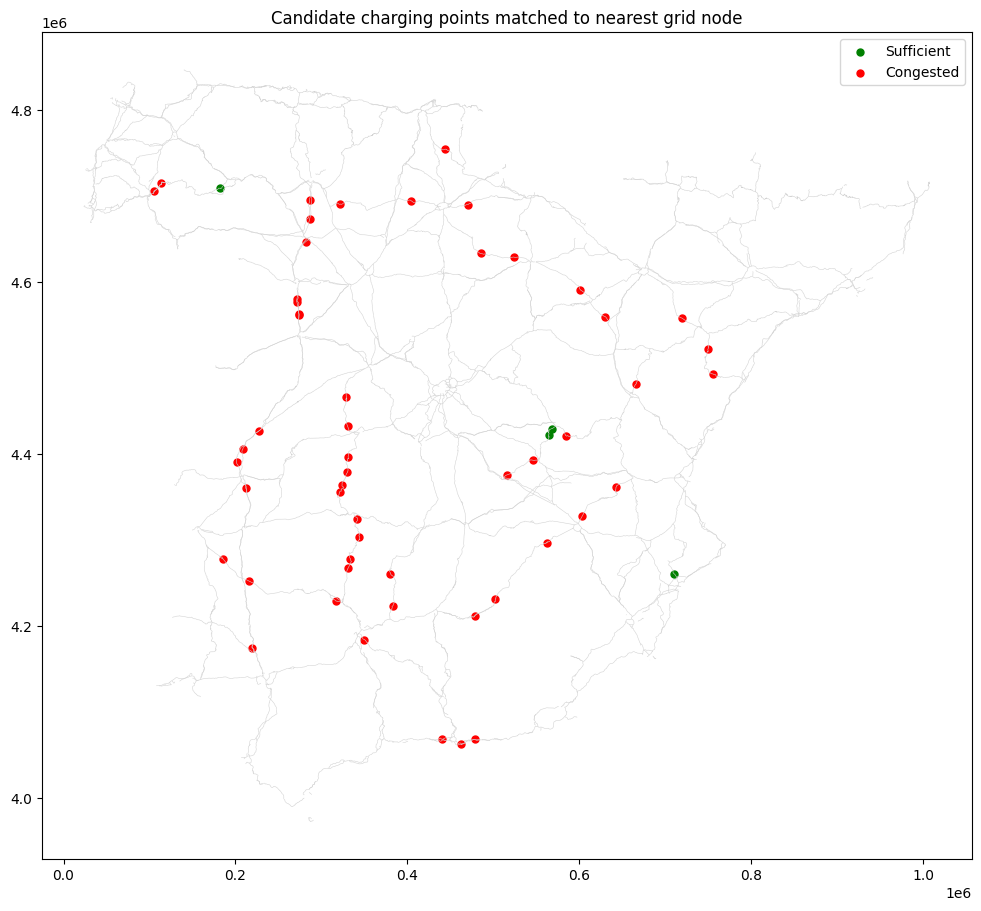

In [ ]:
color_map = {
    "Sufficient": "green",
    "Moderate": "gold",
    "Congested": "red"
}

fig, ax = plt.subplots(figsize=(12, 12))

if mobility_gdf is not None:
    mobility_gdf.plot(ax=ax, linewidth=0.4, color="lightgray")

for status, color in color_map.items():
    subset = matched_gdf[matched_gdf["grid_status"] == status]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=25, label=status)

ax.set_title("Candidate charging points matched to nearest grid node")
ax.legend()
plt.show()

### Interpretation — what the map reveals

The spatial pattern shows that the candidate layer is much stronger from the mobility perspective than from the grid perspective. Most candidate points appear as `Congested`, which means that many of the uncovered interurban corridors identified in Notebook 3 are linked to nearby substations reporting little or no spare available capacity.

This is an important result rather than a negative one. It confirms that the final charging proposal cannot be based on corridor coverage alone. The next stage must therefore prioritize the small subset of candidates that combine mobility need with grid feasibility, while treating the red locations as likely friction points that may require reinforcement, phasing, or strategic deprioritization.

In [ ]:
road_grid_summary = (
    matched_gdf.groupby(["carretera", "grid_status"], as_index=False)
    .agg(
        n_candidates=("candidate_id_n4", "count"),
        mean_capacity_mw=("available_capacity_mw", "mean"),
        max_capacity_mw=("available_capacity_mw", "max"),
        median_dist_to_grid_km=("dist_to_grid_km", "median"),
        min_dist_to_grid_km=("dist_to_grid_km", "min")
    )
)

status_order = pd.CategoricalDtype(
    categories=["Sufficient", "Moderate", "Congested"],
    ordered=True
)

road_grid_summary["grid_status"] = road_grid_summary["grid_status"].astype(status_order)

road_grid_summary = road_grid_summary.sort_values(
    ["grid_status", "n_candidates", "max_capacity_mw"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(road_grid_summary)

,carretera,grid_status,n_candidates,mean_capacity_mw,max_capacity_mw,median_dist_to_grid_km,min_dist_to_grid_km
0,N-420,Sufficient,2,20.30,20.30,7.594202,4.852041
1,N-120,Sufficient,1,35.00,35.00,26.189298,26.189298
2,A-7,Sufficient,1,21.27,21.27,8.549634,8.549634
3,N-502,Congested,10,0.00,0.00,14.522719,4.860793
4,A-66,Congested,7,0.00,0.00,8.148174,3.087142
5,N-420,Congested,6,0.00,0.00,12.501660,4.840594
6,N-120,Congested,5,0.00,0.00,11.152024,5.918473
7,N-322,Congested,5,0.00,0.00,13.216642,5.956221
8,N-630,Congested,5,0.00,0.00,6.661544,4.610059
9,N-232,Congested,4,0.00,0.00,13.646107,4.680474


### Interpretation — corridor-level pattern

The corridor summary helps identify whether congestion is isolated or repeated along the same route. In the current run, several roads contain multiple candidates classified as `Congested`, which suggests that the problem is not only point-specific but corridor-level.

This matters strategically because it means some interurban routes may require a broader deployment or reinforcement strategy rather than a single isolated intervention.

## What this notebook tells us

Notebook 4 converts the candidate layer from a purely mobility-driven proposal into a first infrastructure-feasibility screen. The main conclusion is that the candidate set from Notebook 3 cannot yet be treated as a final charging proposal: many sites appear strategically useful for interurban coverage, but a large share of them are linked to grid nodes with little or no reported spare capacity.

This means the next phase should not simply add chargers everywhere the mobility analysis found a gap. Instead, the final proposal must combine three filters: corridor need, local grid feasibility, and projected 2027 EV demand. The role of this notebook is therefore to identify which mobility candidates look promising, which ones already behave like friction points, and which ones may require reinforcement or prioritization changes in the final network design.